# ☁️ 구름량 vs IoU 실험

## 전략
```
입력: [Q1_고정, Q2_고정, Q3_고정, Q4_구름변화]
  ↓
파이프라인 예측 → Q4 수체 예측
  ↓
비교: Model IoU vs MNDWI IoU
```

## 출력 GIF (3열)
- 왼쪽: RGB + 예측 수체 오버레이
- 가운데: Model Water mIoU 그래프
- 오른쪽: MNDWI Water mIoU 그래프

---
## 01. Imports & Setup

In [1]:
import os
import gc
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import rasterio
from tqdm import tqdm
import matplotlib.pyplot as plt
import imageio
import warnings
warnings.filterwarnings('ignore')

# GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4090


---
## 02. Configuration

In [9]:
# 체크포인트 경로 (수정 필요)
CLOUD_REMOVAL_CKPT = Path("/home/beomsik/data_2_intern_students/beomsik/waterbody_detection/notebook/Prithvi/outputs/v6_1_siamese/best_model.pt")
WATER_DETECTION_CKPT = Path("/home/beomsik/data_2_intern_students/beomsik/waterbody_detection/notebook/multi_modal_decoder/AttentionFusion/checkpoints_v2/best_late_fusion_v2.pt")

# 데이터 경로
SAEMANGEUM_DATA_DIR = Path("./satellite_data/saemangeum_24")

# Model Config
IMG_SIZE = 224
NUM_FRAMES = 4
NUM_CHANNELS = 6
PRITHVI_DIM = 1024
PRITHVI_WITH_CLS = 785

print(f"Cloud Removal: {CLOUD_REMOVAL_CKPT}")
print(f"Water Detection: {WATER_DETECTION_CKPT}")

Cloud Removal: /home/beomsik/data_2_intern_students/beomsik/waterbody_detection/notebook/Prithvi/outputs/v6_1_siamese/best_model.pt
Water Detection: /home/beomsik/data_2_intern_students/beomsik/waterbody_detection/notebook/multi_modal_decoder/AttentionFusion/checkpoints_v2/best_late_fusion_v2.pt


---
## 03. Model Definitions

In [10]:
# ==============================================================================
# Cloud Removal Model (v6.1 Siamese U-Prithvi)
# ==============================================================================

class ConvBlockCloud(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class SiameseUNetEncoder(nn.Module):
    def __init__(self, in_channels=NUM_CHANNELS, num_frames=NUM_FRAMES):
        super().__init__()
        self.num_frames = num_frames
        self.enc1 = ConvBlockCloud(in_channels, 64)
        self.enc2 = ConvBlockCloud(64, 128)
        self.enc3 = ConvBlockCloud(128, 256)
        self.enc4 = ConvBlockCloud(256, 512)
        self.pool = nn.MaxPool2d(2)
        
        self.skip_reduce1 = nn.Sequential(nn.Conv2d(64*num_frames, 64, 1, bias=False), nn.GroupNorm(8, 64), nn.ReLU(inplace=True))
        self.skip_reduce2 = nn.Sequential(nn.Conv2d(128*num_frames, 128, 1, bias=False), nn.GroupNorm(8, 128), nn.ReLU(inplace=True))
        self.skip_reduce3 = nn.Sequential(nn.Conv2d(256*num_frames, 256, 1, bias=False), nn.GroupNorm(8, 256), nn.ReLU(inplace=True))
        self.skip_reduce4 = nn.Sequential(nn.Conv2d(512*num_frames, 512, 1, bias=False), nn.GroupNorm(8, 512), nn.ReLU(inplace=True))
    
    def _encode_single(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        return [e1, e2, e3, e4]
    
    def forward(self, x):
        B, T, C, H, W = x.shape
        all_skips = [[] for _ in range(4)]
        for t in range(T):
            skips_t = self._encode_single(x[:, t])
            for level in range(4):
                all_skips[level].append(skips_t[level])
        
        e1_agg = self.skip_reduce1(torch.cat(all_skips[0], dim=1))
        e2_agg = self.skip_reduce2(torch.cat(all_skips[1], dim=1))
        e3_agg = self.skip_reduce3(torch.cat(all_skips[2], dim=1))
        e4_agg = self.skip_reduce4(torch.cat(all_skips[3], dim=1))
        return e4_agg, [e1_agg, e2_agg, e3_agg, e4_agg]


class UNetDecoder4Out(nn.Module):
    def __init__(self, prithvi_dim=PRITHVI_DIM, out_channels=NUM_CHANNELS):
        super().__init__()
        self.bottleneck = nn.Sequential(nn.Conv2d(prithvi_dim + 512, 512, 1), nn.GroupNorm(8, 512), nn.ReLU(inplace=True))
        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = ConvBlockCloud(256 + 256, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlockCloud(128 + 128, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlockCloud(64 + 64, 64)
        self.out = nn.Conv2d(64, out_channels * NUM_FRAMES, 1)
        self.out_channels = out_channels
    
    def forward(self, prithvi_feat, skips):
        e1, e2, e3, e4 = skips
        B, N, D = prithvi_feat.shape
        if N == PRITHVI_WITH_CLS:
            prithvi_feat = prithvi_feat[:, 1:, :]
        spatial_size = int(np.sqrt(prithvi_feat.shape[1]))
        x = prithvi_feat.permute(0, 2, 1).reshape(B, D, spatial_size, spatial_size)
        
        x = self.bottleneck(torch.cat([x, e4], dim=1))
        x = self.dec4(torch.cat([self.up4(x), e3], dim=1))
        x = self.dec3(torch.cat([self.up3(x), e2], dim=1))
        x = self.dec2(torch.cat([self.up2(x), e1], dim=1))
        
        out = self.out(x)
        B, _, H, W = out.shape
        return out.view(B, NUM_FRAMES, self.out_channels, H, W)


class SiameseUPrithvi(nn.Module):
    def __init__(self):
        super().__init__()
        self.siamese_encoder = SiameseUNetEncoder(in_channels=NUM_CHANNELS, num_frames=NUM_FRAMES)
        
        from terratorch.registry import BACKBONE_REGISTRY
        self.prithvi = BACKBONE_REGISTRY.build(
            'prithvi_eo_v2_300', pretrained=True,
            num_frames=NUM_FRAMES, in_chans=NUM_CHANNELS, img_size=IMG_SIZE
        )
        for param in self.prithvi.parameters():
            param.requires_grad = False
        self.prithvi.eval()
        
        self.decoder = UNetDecoder4Out(prithvi_dim=PRITHVI_DIM, out_channels=NUM_CHANNELS)
    
    def forward(self, frames):
        _, skips = self.siamese_encoder(frames)
        x_prithvi = frames.permute(0, 2, 1, 3, 4)
        self.prithvi.eval()
        with torch.no_grad():
            prithvi_feat = self.prithvi.forward_features(x_prithvi)
        if isinstance(prithvi_feat, (list, tuple)):
            prithvi_feat = prithvi_feat[-1]
        return self.decoder(prithvi_feat, skips)

print("✅ Cloud Removal Model defined")

✅ Cloud Removal Model defined


In [11]:
# ==============================================================================
# Water Detection Model (v2 Late Fusion)
# ==============================================================================

class ConvBlockWater(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class UNetEncoderWater(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.enc1 = ConvBlockWater(in_channels, 64)
        self.enc2 = ConvBlockWater(64, 128)
        self.enc3 = ConvBlockWater(128, 256)
        self.enc4 = ConvBlockWater(256, 512)
        self.bottleneck = ConvBlockWater(512, 1024)
        self.pool = nn.MaxPool2d(2)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        return [e1, e2, e3, e4, b]


class AttentionFusion(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(channels * 2 + 1, channels, 3, padding=1), nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels // 2, 3, padding=1), nn.BatchNorm2d(channels // 2), nn.ReLU(inplace=True),
            nn.Conv2d(channels // 2, 2, 1),
        )
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, opt_feat, sar_feat, cloud_prob):
        if cloud_prob.shape[-2:] != opt_feat.shape[-2:]:
            cloud_prob = F.interpolate(cloud_prob, size=opt_feat.shape[-2:], mode='bilinear', align_corners=False)
        combined = torch.cat([opt_feat, sar_feat, cloud_prob], dim=1)
        weights = self.softmax(self.attention(combined))
        fused = weights[:, 0:1] * opt_feat + weights[:, 1:2] * sar_feat
        return fused, weights


class UNetDecoderWater(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = ConvBlockWater(512 + 512, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlockWater(256 + 256, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlockWater(128 + 128, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlockWater(64 + 64, 64)
        self.out = nn.Conv2d(64, num_classes, 1)
    
    def forward(self, features):
        f1, f2, f3, f4, fb = features
        d4 = self.dec4(torch.cat([self.up4(fb), f4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), f3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), f2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), f1], dim=1))
        return self.out(d1)


class UNetLateFusion(nn.Module):
    def __init__(self, opt_channels=6, sar_channels=2, num_classes=1):
        super().__init__()
        self.opt_encoder = UNetEncoderWater(opt_channels)
        self.sar_encoder = UNetEncoderWater(sar_channels)
        self.fusion1 = AttentionFusion(64)
        self.fusion2 = AttentionFusion(128)
        self.fusion3 = AttentionFusion(256)
        self.fusion4 = AttentionFusion(512)
        self.fusion_b = AttentionFusion(1024)
        self.decoder = UNetDecoderWater(num_classes)
        self.register_buffer('default_cloud', torch.tensor(0.5))
    
    def forward(self, s2, sar, cloud=None):
        B, T, C_opt, H, W = s2.shape
        if cloud is None:
            cloud = torch.full((B, T, 1, H, W), self.default_cloud.item(), device=s2.device, dtype=s2.dtype)
        
        s2_flat = s2.view(B * T, C_opt, H, W)
        sar_flat = sar.view(B * T, sar.shape[2], H, W)
        cloud_flat = cloud.view(B * T, 1, H, W)
        
        opt_feats = self.opt_encoder(s2_flat)
        sar_feats = self.sar_encoder(sar_flat)
        
        f1, w1 = self.fusion1(opt_feats[0], sar_feats[0], cloud_flat)
        f2, w2 = self.fusion2(opt_feats[1], sar_feats[1], cloud_flat)
        f3, w3 = self.fusion3(opt_feats[2], sar_feats[2], cloud_flat)
        f4, w4 = self.fusion4(opt_feats[3], sar_feats[3], cloud_flat)
        fb, wb = self.fusion_b(opt_feats[4], sar_feats[4], cloud_flat)
        
        out = self.decoder([f1, f2, f3, f4, fb]).view(B, T, H, W)
        
        attn_weights = {
            'level1': w1.view(B, T, 2, w1.shape[-2], w1.shape[-1]),
            'level2': w2.view(B, T, 2, w2.shape[-2], w2.shape[-1]),
            'level3': w3.view(B, T, 2, w3.shape[-2], w3.shape[-1]),
            'level4': w4.view(B, T, 2, w4.shape[-2], w4.shape[-1]),
            'bottleneck': wb.view(B, T, 2, wb.shape[-2], wb.shape[-1]),
        }
        return out, attn_weights

print("✅ Water Detection Model defined")

✅ Water Detection Model defined


---
## 04. Pipeline

In [12]:
class MemoryEfficientPipeline:
    """Cloud Removal → Water Detection 순차 실행"""
    
    def __init__(self, cloud_removal_ckpt, water_detection_ckpt, device='cuda'):
        self.cloud_removal_ckpt = cloud_removal_ckpt
        self.water_detection_ckpt = water_detection_ckpt
        self.device = device
        print(f"📌 Pipeline initialized")
    
    def _load_cloud_removal(self):
        model = SiameseUPrithvi().to(self.device)
        ckpt = torch.load(self.cloud_removal_ckpt, map_location=self.device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt)
        model.eval()
        return model
    
    def _load_water_detection(self):
        model = UNetLateFusion(opt_channels=6, sar_channels=2, num_classes=1).to(self.device)
        ckpt = torch.load(self.water_detection_ckpt, map_location=self.device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt)
        model.eval()
        return model
    
    def _clear_gpu(self):
        gc.collect()
        torch.cuda.empty_cache()
    
    @torch.no_grad()
    def predict(self, cloudy_s2, sar, verbose=False):
        if isinstance(cloudy_s2, np.ndarray):
            cloudy_s2 = torch.from_numpy(cloudy_s2).float()
        if isinstance(sar, np.ndarray):
            sar = torch.from_numpy(sar).float()
        
        squeeze_batch = False
        if cloudy_s2.dim() == 4:
            cloudy_s2 = cloudy_s2.unsqueeze(0)
            sar = sar.unsqueeze(0)
            squeeze_batch = True
        
        # Step 1: Cloud Removal
        cloud_model = self._load_cloud_removal()
        cloudy_gpu = cloudy_s2.to(self.device)
        restored_s2 = torch.clamp(cloud_model(cloudy_gpu), 0, 1)
        restored_cpu = restored_s2.cpu()
        del cloud_model, cloudy_gpu, restored_s2
        self._clear_gpu()
        
        # Step 2: Water Detection
        water_model = self._load_water_detection()
        restored_gpu = restored_cpu.to(self.device)
        sar_gpu = sar.to(self.device)
        water_logits, attn_weights = water_model(restored_gpu, sar_gpu, cloud=None)
        water_prob = torch.sigmoid(water_logits)
        water_mask = (water_prob > 0.5).long()
        
        water_prob_cpu = water_prob.cpu()
        water_mask_cpu = water_mask.cpu()
        attn_cpu = {k: v.cpu() for k, v in attn_weights.items()}
        
        del water_model, restored_gpu, sar_gpu
        self._clear_gpu()
        
        if squeeze_batch:
            restored_cpu = restored_cpu.squeeze(0)
            water_prob_cpu = water_prob_cpu.squeeze(0)
            water_mask_cpu = water_mask_cpu.squeeze(0)
            cloudy_s2 = cloudy_s2.squeeze(0)
            attn_cpu = {k: v.squeeze(0) for k, v in attn_cpu.items()}
        
        return {
            'cloudy_s2': cloudy_s2.numpy(),
            'restored_s2': restored_cpu.numpy(),
            'water_prob': water_prob_cpu.numpy(),
            'water_mask': water_mask_cpu.numpy(),
            'attn_weights': attn_cpu
        }

# Pipeline 생성
pipeline = MemoryEfficientPipeline(
    cloud_removal_ckpt=CLOUD_REMOVAL_CKPT,
    water_detection_ckpt=WATER_DETECTION_CKPT,
    device=DEVICE
)
print("✅ Pipeline ready!")

📌 Pipeline initialized
✅ Pipeline ready!


---
## 05. 데이터 로드

In [13]:
def load_all_frames(data_dir, target_size=(224, 224)):
    """24프레임 로드"""
    frame_dirs = sorted(glob.glob(os.path.join(data_dir, '*')))
    frames = {}
    
    for frame_dir in frame_dirs:
        if not os.path.isdir(frame_dir):
            continue
        frame_name = os.path.basename(frame_dir)
        data = {'name': frame_name, 'path': frame_dir}
        
        # S2
        s2_path = os.path.join(frame_dir, 's2.tif')
        if os.path.exists(s2_path):
            with rasterio.open(s2_path) as src:
                s2 = src.read().astype(np.float32)
            s2 = np.clip(s2 / 10000.0, 0, 1)
            if s2.shape[1:] != target_size:
                s2_t = torch.from_numpy(s2).unsqueeze(0)
                s2_t = F.interpolate(s2_t, size=target_size, mode='bilinear', align_corners=False)
                s2 = s2_t.squeeze(0).numpy()
            data['s2'] = s2
        
        # S1
        s1_path = os.path.join(frame_dir, 's1.tif')
        if os.path.exists(s1_path):
            with rasterio.open(s1_path) as src:
                s1 = src.read().astype(np.float32)
            s1 = np.clip((s1 + 35) / 40.0, 0, 1)
            if s1.shape[1:] != target_size:
                s1_t = torch.from_numpy(s1).unsqueeze(0)
                s1_t = F.interpolate(s1_t, size=target_size, mode='bilinear', align_corners=False)
                s1 = s1_t.squeeze(0).numpy()
            data['s1'] = s1
        
        # Water GT
        water_path = os.path.join(frame_dir, 'water_gt.tif')
        if os.path.exists(water_path):
            with rasterio.open(water_path) as src:
                water = src.read(1).astype(np.float32)
            if water.shape != target_size:
                water_t = torch.from_numpy(water).unsqueeze(0).unsqueeze(0)
                water_t = F.interpolate(water_t, size=target_size, mode='nearest')
                water = water_t.squeeze().numpy()
            data['water_gt'] = water
        
        # Cloud
        cloud_path = os.path.join(frame_dir, 'cloud.tif')
        if os.path.exists(cloud_path):
            with rasterio.open(cloud_path) as src:
                cloud = src.read(1).astype(np.float32)
            if cloud.shape != target_size:
                cloud_t = torch.from_numpy(cloud).unsqueeze(0).unsqueeze(0)
                cloud_t = F.interpolate(cloud_t, size=target_size, mode='bilinear', align_corners=False)
                cloud = cloud_t.squeeze().numpy()
            data['cloud'] = cloud
        
        frames[frame_name] = data
    
    return frames

# 로드
frames = load_all_frames(str(SAEMANGEUM_DATA_DIR))
print(f"✅ Loaded {len(frames)} frames")

# S2 + S1 둘 다 있는 프레임만
frames = {k: v for k, v in frames.items() if 's2' in v and 's1' in v}
print(f"✅ Complete frames: {len(frames)}")

✅ Loaded 24 frames
✅ Complete frames: 21


In [14]:
# 참조 프레임 선택 (구름 적고 수체 있는 프레임)
frame_stats = []
for name, data in frames.items():
    cloud_pct = data.get('cloud', np.array([0])).mean()
    water_pct = data.get('water_gt', np.array([0])).mean() * 100
    frame_stats.append((name, cloud_pct, water_pct))

# 구름 적고 수체 많은 순 정렬
good_frames = [(n, c, w) for n, c, w in frame_stats if c < 30 and w > 0]
good_frames.sort(key=lambda x: (-x[2], x[1]))

if len(good_frames) >= 3:
    REFERENCE_FRAMES = [good_frames[0][0], good_frames[1][0], good_frames[2][0]]
else:
    sorted_by_cloud = sorted(frame_stats, key=lambda x: x[1])
    REFERENCE_FRAMES = [sorted_by_cloud[0][0], sorted_by_cloud[1][0], sorted_by_cloud[2][0]]

print(f"\n⭐ Reference Frames:")
for i, rf in enumerate(REFERENCE_FRAMES):
    data = frames[rf]
    cloud = data.get('cloud', np.array([0])).mean()
    water = data.get('water_gt', np.array([0])).mean() * 100
    print(f"   Q{i+1}: {rf} (Cloud: {cloud:.1f}%, Water: {water:.1f}%)")


⭐ Reference Frames:
   Q1: 05_0302 (Cloud: 4.0%, Water: 60.2%)
   Q2: 07_0401 (Cloud: 7.0%, Water: 60.1%)
   Q3: 24_1212 (Cloud: 4.6%, Water: 59.6%)


---
## 06. 인공 구름 생성 함수

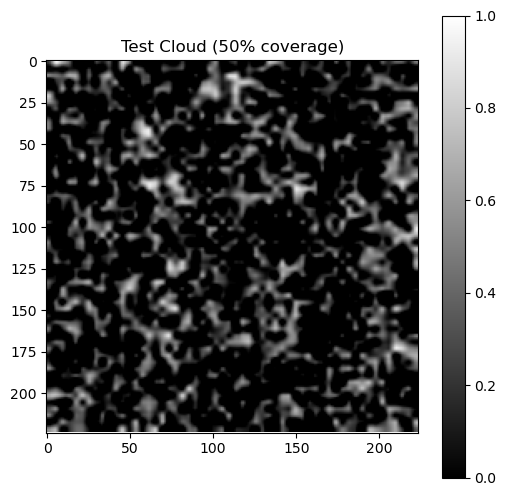

In [15]:
def generate_realistic_cloud(height, width, cloud_coverage=0.5, seed=None):
    """Multi-scale 구름 생성"""
    if seed is not None:
        np.random.seed(seed)
    
    cloud = np.zeros((height, width), dtype=np.float32)
    
    for scale in [4, 8, 16, 32]:
        h, w = max(1, height // scale), max(1, width // scale)
        noise = np.random.rand(h, w)
        noise_t = torch.from_numpy(noise).float().unsqueeze(0).unsqueeze(0)
        noise_up = F.interpolate(noise_t, size=(height, width), mode='bilinear', align_corners=False)
        cloud += noise_up.squeeze().numpy() / scale
    
    cloud = (cloud - cloud.min()) / (cloud.max() - cloud.min() + 1e-8)
    
    if cloud_coverage > 0:
        threshold = np.percentile(cloud, (1 - cloud_coverage) * 100)
        cloud_mask = np.clip((cloud - threshold) / (1 - threshold + 1e-8), 0, 1)
    else:
        cloud_mask = np.zeros_like(cloud)
    
    return cloud_mask.astype(np.float32)


def apply_cloud_to_image(s2_image, cloud_mask, cloud_brightness=0.95):
    """S2 이미지에 구름 적용"""
    cloud_3d = cloud_mask[np.newaxis, :, :]
    cloudy = s2_image * (1 - cloud_3d) + cloud_brightness * cloud_3d
    return np.clip(cloudy, 0, 1).astype(np.float32)


# 테스트
test_cloud = generate_realistic_cloud(224, 224, cloud_coverage=0.5, seed=42)
plt.figure(figsize=(6, 6))
plt.imshow(test_cloud, cmap='gray')
plt.title(f'Test Cloud (50% coverage)')
plt.colorbar()
plt.show()

---
## 07. MNDWI 계산 함수

In [16]:
def compute_mndwi(s2_image, threshold=0.3):
    """
    MNDWI = (Green - SWIR1) / (Green + SWIR1)
    
    S2 bands: [B2, B3, B4, B8, B11, B12] = [Blue, Green, Red, NIR, SWIR1, SWIR2]
    Index:    [0,  1,  2,  3,  4,   5]
    """
    green = s2_image[1]   # Index 1 = Green (B3)
    swir1 = s2_image[4]   # Index 4 = SWIR1 (B11)
    
    mndwi = (green - swir1) / (green + swir1 + 1e-8)
    mndwi = np.clip(mndwi, -1, 1)
    
    water_mask = (mndwi > threshold).astype(np.float32)
    
    return mndwi, water_mask


def compute_iou(pred, gt):
    """Water IoU"""
    pred_b = (pred > 0.5).astype(np.int64)
    gt_b = (gt > 0.5).astype(np.int64)
    
    intersection = ((pred_b == 1) & (gt_b == 1)).sum()
    union = ((pred_b == 1) | (gt_b == 1)).sum()
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

print("✅ MNDWI & IoU functions defined")

✅ MNDWI & IoU functions defined


---
## 08. 구름량 vs IoU 실험 + GIF 생성

In [17]:
def run_cloud_experiment(pipeline, ref_frames_data, query_frame_data, water_gt,
                          coverage_range=np.arange(0, 1.01, 0.05),
                          output_dir='./frames/cloud_experiment',
                          gif_path='./gifs/cloud_vs_iou.gif',
                          mndwi_threshold=0):
    """
    구름량 vs IoU 실험 + GIF 생성
    
    3열 시각화:
    - 왼쪽: RGB + 예측 수체 오버레이
    - 가운데: Model Water mIoU
    - 오른쪽: MNDWI Water mIoU
    """
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.dirname(gif_path) if os.path.dirname(gif_path) else '.', exist_ok=True)
    
    H, W = query_frame_data['s2'].shape[1:]
    
    results = {
        'coverage': [],
        'model_iou': [],
        'mndwi_iou': []
    }
    
    images = []
    
    for i, coverage in enumerate(tqdm(coverage_range, desc="Cloud Experiment")):
        # 1. 구름 생성 & 적용
        cloud_mask = generate_realistic_cloud(H, W, cloud_coverage=coverage, seed=42)
        cloudy_s2 = apply_cloud_to_image(query_frame_data['s2'], cloud_mask)
        
        # 2. 입력 준비: [ref1, ref2, ref3, query_cloudy]
        s2_input = np.stack([
            ref_frames_data[0]['s2'],
            ref_frames_data[1]['s2'],
            ref_frames_data[2]['s2'],
            cloudy_s2
        ], axis=0)
        
        s1_input = np.stack([
            ref_frames_data[0]['s1'],
            ref_frames_data[1]['s1'],
            ref_frames_data[2]['s1'],
            query_frame_data['s1']
        ], axis=0)
        
        # 3. 모델 예측
        gc.collect()
        torch.cuda.empty_cache()
        
        pred_results = pipeline.predict(s2_input, s1_input, verbose=False)
        water_pred = pred_results['water_mask'][3]
        water_prob = pred_results['water_prob'][3]
        
        # 4. MNDWI 계산
        _, mndwi_water = compute_mndwi(cloudy_s2, threshold=mndwi_threshold)
        
        # 5. IoU 계산
        model_iou = compute_iou(water_prob, water_gt)
        mndwi_iou = compute_iou(mndwi_water, water_gt)
        
        results['coverage'].append(coverage * 100)
        results['model_iou'].append(model_iou)
        results['mndwi_iou'].append(mndwi_iou)
        
        # 6. 시각화 (3열)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # ===== 왼쪽: RGB + 예측 수체 =====
        rgb = np.clip(cloudy_s2[[2,1,0]].transpose(1,2,0) * 2.5, 0, 1)
        axes[0].imshow(rgb)
        
        # 구름 영역 (빨강 반투명)
        cloud_overlay = np.zeros((H, W, 4))
        cloud_overlay[cloud_mask > 0.3] = [1, 0.4, 0.4, 0.4]
        axes[0].imshow(cloud_overlay)
        
        # 예측 수체 (시안 반투명)
        water_overlay = np.zeros((H, W, 4))
        water_overlay[water_pred == 1] = [0, 1, 1, 0.6]
        axes[0].imshow(water_overlay)
        
        axes[0].set_title(f'Cloud: {coverage*100:.0f}% | RGB + Predicted Water', fontsize=14)
        axes[0].axis('off')
        
        # ===== 가운데: Model IoU =====
        axes[1].plot(results['coverage'], results['model_iou'], 'b-', linewidth=2.5, label='Model IoU')
        axes[1].scatter(results['coverage'][-1], results['model_iou'][-1], 
                       color='blue', s=150, zorder=5, edgecolor='white', linewidth=2)
        axes[1].axvline(x=coverage*100, color='red', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Cloud Coverage [%]', fontsize=12)
        axes[1].set_ylabel('mIoU', fontsize=12)
        axes[1].set_xlim(0, 100)
        axes[1].set_ylim(0, 1)
        axes[1].grid(True, alpha=0.3)
        axes[1].set_title(f'Model Water mIoU: {model_iou:.3f}', fontsize=14)
        axes[1].legend(loc='lower left')
        
        # ===== 오른쪽: MNDWI IoU =====
        axes[2].plot(results['coverage'], results['mndwi_iou'], 'g-', linewidth=2.5, label='MNDWI IoU')
        axes[2].scatter(results['coverage'][-1], results['mndwi_iou'][-1], 
                       color='green', s=150, zorder=5, edgecolor='white', linewidth=2)
        axes[2].axvline(x=coverage*100, color='red', linestyle='--', alpha=0.5)
        axes[2].set_xlabel('Cloud Coverage [%]', fontsize=12)
        axes[2].set_ylabel('mIoU', fontsize=12)
        axes[2].set_xlim(0, 100)
        axes[2].set_ylim(0, 1)
        axes[2].grid(True, alpha=0.3)
        axes[2].set_title(f'MNDWI Water mIoU: {mndwi_iou:.3f}', fontsize=14)
        axes[2].legend(loc='lower left')
        
        plt.suptitle(f'Cloud Coverage: {coverage*100:.0f}%', fontsize=16, y=1.02)
        plt.tight_layout()
        
        frame_path = f'{output_dir}/frame_{i:03d}.png'
        plt.savefig(frame_path, dpi=120, bbox_inches='tight', facecolor='white')
        plt.close()
        
        images.append(imageio.imread(frame_path))
    
    # GIF 생성
    imageio.mimsave(gif_path, images, fps=2, loop=0)
    print(f"\n✅ GIF saved: {gif_path}")
    
    return results

In [18]:
def plot_final_comparison(results, save_path=None):
    """Model vs MNDWI 비교 그래프"""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(results['coverage'], results['model_iou'], 'b-', linewidth=2.5, 
            label='Our Model (Cloud Removal + SAR Fusion)', marker='o', markersize=4)
    ax.plot(results['coverage'], results['mndwi_iou'], 'g--', linewidth=2.5, 
            label='MNDWI (Optical Only)', marker='s', markersize=4)
    
    # Model이 더 좋은 영역 채우기
    ax.fill_between(results['coverage'], results['model_iou'], results['mndwi_iou'],
                    where=np.array(results['model_iou']) > np.array(results['mndwi_iou']),
                    alpha=0.3, color='blue', label='Model Advantage')
    
    ax.set_xlabel('Cloud Coverage [%]', fontsize=14)
    ax.set_ylabel('Water mIoU', fontsize=14)
    ax.set_title('Water Detection Performance: Model vs MNDWI', fontsize=16)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Comparison saved: {save_path}")
    
    plt.show()

---
## 09. 실험 실행

In [19]:
# 참조 프레임 데이터
ref_frames_data = [
    {'s2': frames[REFERENCE_FRAMES[0]]['s2'], 's1': frames[REFERENCE_FRAMES[0]]['s1']},
    {'s2': frames[REFERENCE_FRAMES[1]]['s2'], 's1': frames[REFERENCE_FRAMES[1]]['s1']},
    {'s2': frames[REFERENCE_FRAMES[2]]['s2'], 's1': frames[REFERENCE_FRAMES[2]]['s1']},
]

# 쿼리 프레임 (구름 적용할 깨끗한 프레임)
query_name = REFERENCE_FRAMES[0]  # 첫 번째 참조 프레임 사용
query_frame_data = {
    's2': frames[query_name]['s2'],
    's1': frames[query_name]['s1']
}

# Water GT
water_gt = frames[query_name]['water_gt']

print(f"Reference frames: {REFERENCE_FRAMES}")
print(f"Query frame: {query_name}")
print(f"Water GT shape: {water_gt.shape}")
print(f"Water ratio: {water_gt.mean()*100:.1f}%")

Reference frames: ['05_0302', '07_0401', '24_1212']
Query frame: 05_0302
Water GT shape: (224, 224)
Water ratio: 60.2%


In [30]:
# 실험 실행
os.makedirs('./gifs', exist_ok=True)

results = run_cloud_experiment(
    pipeline=pipeline,
    ref_frames_data=ref_frames_data,
    query_frame_data=query_frame_data,
    water_gt=water_gt,
    coverage_range=np.arange(0, 1.01, 0.05),  # 0%, 5%, 10%, ..., 100%
    output_dir='./frames/cloud_experiment',
    gif_path='./gifs/cloud_vs_iou.gif',
    mndwi_threshold=0.3
)

Cloud Experiment: 100%|██████████████████████████████████████████████████████████████████| 21/21 [01:50<00:00,  5.26s/it]



✅ GIF saved: ./gifs/cloud_vs_iou.gif


총 수체 픽셀: 38580
총 구름 픽셀: 9079
수체 위 구름: 6967
수체 위 구름 비율: 18.1%


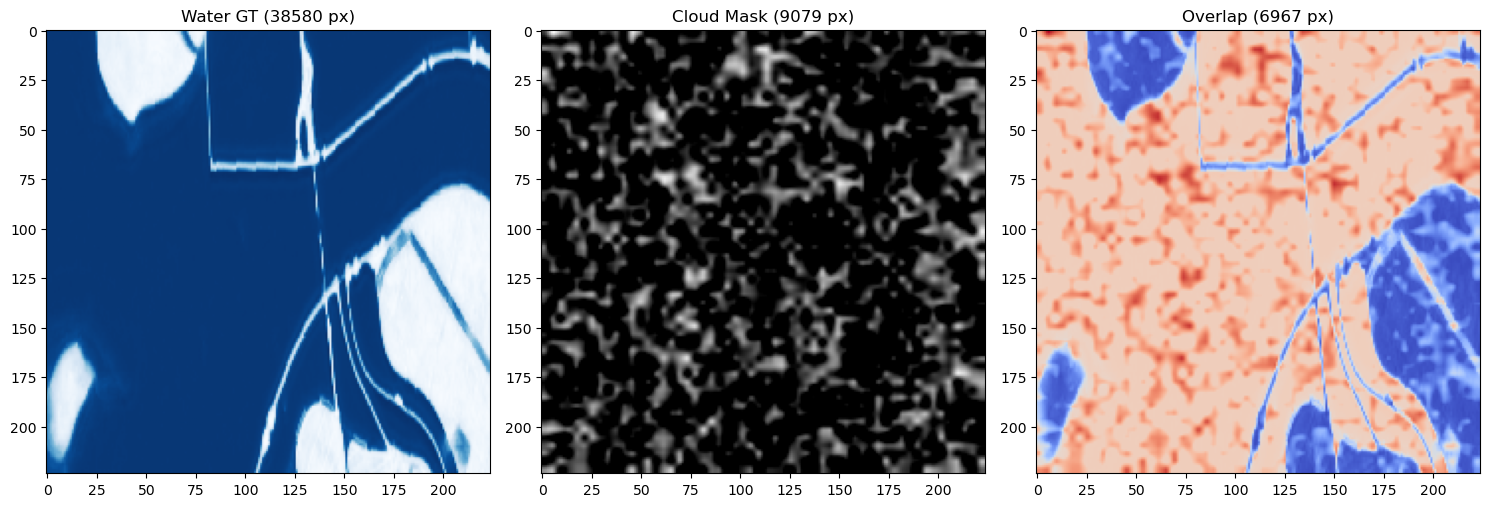

In [26]:
# 테스트용 구름 생성
H, W = 224, 224
query_name = REFERENCE_FRAMES[0]
water_gt = frames[query_name]['water_gt']

# 구름 생성 (50% coverage)
cloud_mask = generate_realistic_cloud(H, W, cloud_coverage=0.5, seed=42)

# 겹침 확인
cloud_on_water = ((cloud_mask > 0.3) & (water_gt > 0.5)).sum()
total_water = (water_gt > 0.5).sum()
total_cloud = (cloud_mask > 0.3).sum()

print(f"총 수체 픽셀: {total_water}")
print(f"총 구름 픽셀: {total_cloud}")
print(f"수체 위 구름: {cloud_on_water}")
print(f"수체 위 구름 비율: {cloud_on_water/total_water*100:.1f}%")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(water_gt, cmap='Blues')
axes[0].set_title(f'Water GT ({total_water} px)')
axes[1].imshow(cloud_mask, cmap='gray')
axes[1].set_title(f'Cloud Mask ({total_cloud} px)')
axes[2].imshow(water_gt + cloud_mask * 0.5, cmap='coolwarm')
axes[2].set_title(f'Overlap ({cloud_on_water} px)')
plt.tight_layout()
plt.show()

✅ Comparison saved: ./gifs/cloud_vs_iou_comparison.png


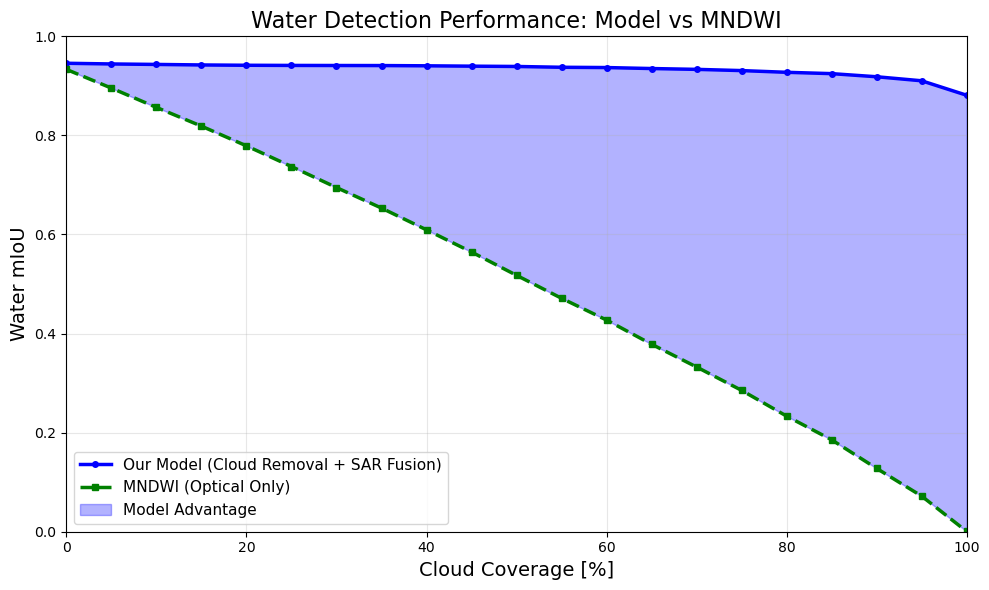

In [31]:
# 최종 비교 그래프
plot_final_comparison(results, save_path='./gifs/cloud_vs_iou_comparison.png')

In [32]:
# 결과 요약
print("\n📊 Results Summary:")
print(f"{'Coverage':<12} {'Model IoU':<12} {'MNDWI IoU':<12} {'Diff':<12}")
print("-" * 48)
for i in range(0, len(results['coverage']), 4):  # 20% 간격 출력
    c = results['coverage'][i]
    m = results['model_iou'][i]
    n = results['mndwi_iou'][i]
    print(f"{c:<12.0f} {m:<12.3f} {n:<12.3f} {m-n:<+12.3f}")


📊 Results Summary:
Coverage     Model IoU    MNDWI IoU    Diff        
------------------------------------------------
0            0.946        0.933        +0.012      
20           0.942        0.779        +0.163      
40           0.941        0.609        +0.331      
60           0.937        0.427        +0.510      
80           0.927        0.233        +0.694      
100          0.881        0.001        +0.880      


---
## 📊 Summary

### 출력 파일
```
./gifs/
├── cloud_vs_iou.gif              # 3열 애니메이션
└── cloud_vs_iou_comparison.png   # Model vs MNDWI 비교
```

### 실험 설계
- **입력**: [Q1_고정, Q2_고정, Q3_고정, Q4_구름변화]
- **구름량**: 0% ~ 100% (5% 단위)
- **비교**: Model IoU vs MNDWI IoU

### 예상 결과
- 구름 없을 때: Model ≈ MNDWI
- 구름 많을 때: Model >> MNDWI (SAR 덕분)

In [35]:
# ==============================================================================
# 비선형 구름 생성 함수
# ==============================================================================
from scipy.ndimage import binary_dilation

def generate_nonlinear_cloud(height, width, water_gt, cloud_coverage=0.5, seed=None):
    """
    비선형적으로 수체 영역에 구름 생성
    """
    if seed is not None:
        np.random.seed(seed)
    
    # 1. 기본 Perlin-like 노이즈
    cloud = np.zeros((height, width), dtype=np.float32)
    for scale in [4, 8, 16, 32]:
        h, w = max(1, height // scale), max(1, width // scale)
        noise = np.random.rand(h, w)
        noise_t = torch.from_numpy(noise).float().unsqueeze(0).unsqueeze(0)
        noise_up = F.interpolate(noise_t, size=(height, width), mode='bilinear', align_corners=False)
        cloud += noise_up.squeeze().numpy() / scale
    
    cloud = (cloud - cloud.min()) / (cloud.max() - cloud.min() + 1e-8)
    
    # 2. 수체 영역 가중치 (수체 위에 구름 집중)
    water_mask = (water_gt > 0.5).astype(np.float32)
    dilated_water = binary_dilation(water_mask, iterations=10).astype(np.float32)
    
    weight = np.ones_like(cloud)
    weight[dilated_water > 0] = 2.0
    weight[water_mask > 0] = 5.0
    
    cloud = cloud * weight
    cloud = (cloud - cloud.min()) / (cloud.max() - cloud.min() + 1e-8)
    
    # 3. 비선형 coverage 적용 (S-curve)
    if cloud_coverage > 0:
        adjusted_coverage = 1 / (1 + np.exp(-10 * (cloud_coverage - 0.5)))
        adjusted_coverage = adjusted_coverage * 0.95 + 0.025
        
        threshold = np.percentile(cloud, (1 - adjusted_coverage) * 100)
        cloud_mask = np.clip((cloud - threshold) / (1 - threshold + 1e-8), 0, 1)
        
        intensity = 0.5 + 0.5 * cloud_coverage
        cloud_mask = cloud_mask * intensity
    else:
        cloud_mask = np.zeros_like(cloud)
    
    return cloud_mask.astype(np.float32)


def apply_cloud_nonlinear(s2_image, cloud_mask, base_brightness=0.85):
    """비선형 구름 적용"""
    cloud_intensity = cloud_mask ** 0.7
    
    cloud_3d = np.zeros_like(s2_image)
    for b in range(s2_image.shape[0]):
        if b >= 4:  # SWIR bands
            cloud_3d[b] = cloud_intensity * (base_brightness + 0.1)
        else:
            cloud_3d[b] = cloud_intensity * base_brightness
    
    cloudy = s2_image * (1 - cloud_intensity[np.newaxis, :, :]) + cloud_3d
    return np.clip(cloudy, 0, 1).astype(np.float32)


# ==============================================================================
# 수정된 실험 함수 (비선형 버전)
# ==============================================================================

def run_cloud_experiment_nonlinear(pipeline, ref_frames_data, query_frame_data, water_gt,
                                    coverage_range=np.arange(0, 1.01, 0.05),
                                    output_dir='./frames/cloud_experiment_nonlinear',
                                    gif_path='./gifs/cloud_vs_iou_nonlinear.gif',
                                    mndwi_threshold=0.3):
    """비선형 구름 + 수체 집중 실험"""
    
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.dirname(gif_path) if os.path.dirname(gif_path) else '.', exist_ok=True)
    
    H, W = query_frame_data['s2'].shape[1:]
    
    results = {
        'coverage': [],
        'model_iou': [],
        'mndwi_iou': []
    }
    
    images = []
    
    for i, coverage in enumerate(tqdm(coverage_range, desc="Cloud Experiment (Nonlinear)")):
        # 1. 비선형 구름 생성 & 적용
        cloud_mask = generate_nonlinear_cloud(H, W, water_gt, cloud_coverage=coverage, seed=42)
        cloudy_s2 = apply_cloud_nonlinear(query_frame_data['s2'], cloud_mask)
        
        # 2. 입력 준비
        s2_input = np.stack([
            ref_frames_data[0]['s2'],
            ref_frames_data[1]['s2'],
            ref_frames_data[2]['s2'],
            cloudy_s2
        ], axis=0)
        
        s1_input = np.stack([
            ref_frames_data[0]['s1'],
            ref_frames_data[1]['s1'],
            ref_frames_data[2]['s1'],
            query_frame_data['s1']
        ], axis=0)
        
        # 3. 모델 예측
        gc.collect()
        torch.cuda.empty_cache()
        
        pred_results = pipeline.predict(s2_input, s1_input, verbose=False)
        water_pred = pred_results['water_mask'][3]
        water_prob = pred_results['water_prob'][3]
        
        # 4. MNDWI 계산
        _, mndwi_water = compute_mndwi(cloudy_s2, threshold=mndwi_threshold)
        
        # 5. IoU 계산
        model_iou = compute_iou(water_prob, water_gt)
        mndwi_iou = compute_iou(mndwi_water, water_gt)
        
        results['coverage'].append(coverage * 100)
        results['model_iou'].append(model_iou)
        results['mndwi_iou'].append(mndwi_iou)
        
        # 6. 시각화 (3열)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # 왼쪽: RGB + 예측 수체
        rgb = np.clip(cloudy_s2[[2,1,0]].transpose(1,2,0) * 2.5, 0, 1)
        axes[0].imshow(rgb)
        
        cloud_overlay = np.zeros((H, W, 4))
        cloud_overlay[cloud_mask > 0.3] = [1, 0.4, 0.4, 0.4]
        axes[0].imshow(cloud_overlay)
        
        water_overlay = np.zeros((H, W, 4))
        water_overlay[water_pred == 1] = [0, 1, 1, 0.6]
        axes[0].imshow(water_overlay)
        
        axes[0].set_title(f'Cloud: {coverage*100:.0f}% | RGB + Predicted Water', fontsize=14)
        axes[0].axis('off')
        
        # 가운데: Model IoU
        axes[1].plot(results['coverage'], results['model_iou'], 'b-', linewidth=2.5, label='Model IoU')
        axes[1].scatter(results['coverage'][-1], results['model_iou'][-1], 
                       color='blue', s=150, zorder=5, edgecolor='white', linewidth=2)
        axes[1].axvline(x=coverage*100, color='red', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Cloud Coverage [%]', fontsize=12)
        axes[1].set_ylabel('mIoU', fontsize=12)
        axes[1].set_xlim(0, 100)
        axes[1].set_ylim(0, 1)
        axes[1].grid(True, alpha=0.3)
        axes[1].set_title(f'Model Water mIoU: {model_iou:.3f}', fontsize=14)
        axes[1].legend(loc='lower left')
        
        # 오른쪽: MNDWI IoU
        axes[2].plot(results['coverage'], results['mndwi_iou'], 'g-', linewidth=2.5, label='MNDWI IoU')
        axes[2].scatter(results['coverage'][-1], results['mndwi_iou'][-1], 
                       color='green', s=150, zorder=5, edgecolor='white', linewidth=2)
        axes[2].axvline(x=coverage*100, color='red', linestyle='--', alpha=0.5)
        axes[2].set_xlabel('Cloud Coverage [%]', fontsize=12)
        axes[2].set_ylabel('mIoU', fontsize=12)
        axes[2].set_xlim(0, 100)
        axes[2].set_ylim(0, 1)
        axes[2].grid(True, alpha=0.3)
        axes[2].set_title(f'MNDWI Water mIoU: {mndwi_iou:.3f}', fontsize=14)
        axes[2].legend(loc='lower left')
        
        plt.suptitle(f'Cloud Coverage: {coverage*100:.0f}%', fontsize=16, y=1.02)
        plt.tight_layout()
        
        frame_path = f'{output_dir}/frame_{i:03d}.png'
        plt.savefig(frame_path, dpi=120, bbox_inches='tight', facecolor='white')
        plt.close()
        
        images.append(imageio.imread(frame_path))
    
    # GIF 생성
    imageio.mimsave(gif_path, images, fps=2, loop=0)
    print(f"\n✅ GIF saved: {gif_path}")
    
    return results


# ==============================================================================
# 실험 실행
# ==============================================================================

# 데이터 준비
query_name = REFERENCE_FRAMES[0]
query_frame_data = {
    's2': frames[query_name]['s2'],
    's1': frames[query_name]['s1']
}
water_gt = frames[query_name]['water_gt']

ref_frames_data = [
    {'s2': frames[REFERENCE_FRAMES[0]]['s2'], 's1': frames[REFERENCE_FRAMES[0]]['s1']},
    {'s2': frames[REFERENCE_FRAMES[1]]['s2'], 's1': frames[REFERENCE_FRAMES[1]]['s1']},
    {'s2': frames[REFERENCE_FRAMES[2]]['s2'], 's1': frames[REFERENCE_FRAMES[2]]['s1']},
]

# 실험 실행
os.makedirs('./gifs', exist_ok=True)

results = run_cloud_experiment_nonlinear(
    pipeline=pipeline,
    ref_frames_data=ref_frames_data,
    query_frame_data=query_frame_data,
    water_gt=water_gt,
    coverage_range=np.arange(0, 1.01, 0.05),
    output_dir='./frames/cloud_experiment_nonlinear',
    gif_path='./gifs/cloud_vs_iou_nonlinear.gif',
    mndwi_threshold=0.3
)

# 결과 출력
print("\n📊 Results Summary:")
print(f"{'Coverage':<12} {'Model IoU':<12} {'MNDWI IoU':<12} {'Diff':<12}")
print("-" * 48)
for i in range(0, len(results['coverage']), 4):
    c = results['coverage'][i]
    m = results['model_iou'][i]
    n = results['mndwi_iou'][i]
    print(f"{c:<12.0f} {m:<12.3f} {n:<12.3f} {m-n:<+12.3f}")

Cloud Experiment (Nonlinear): 100%|██████████████████████████████████████████████████████| 21/21 [01:42<00:00,  4.89s/it]



✅ GIF saved: ./gifs/cloud_vs_iou_nonlinear.gif

📊 Results Summary:
Coverage     Model IoU    MNDWI IoU    Diff        
------------------------------------------------
0            0.946        0.933        +0.012      
20           0.941        0.855        +0.086      
40           0.930        0.610        +0.320      
60           0.884        0.095        +0.789      
80           0.834        0.006        +0.828      
100          0.818        0.002        +0.816      
